# Task 1
Tom

## Can the series be grouped?

To answer this we look at the log-returns from three angles:

1. The log-return correlation matrix, which series move together.
2. Log-return volatility, how big the daily moves are for each series.
3. A visual check on the correlation matrix to confirm the groups.


In [1]:
# Load data and clean the 1000-anomaly the same way as in cell 1 and cell 2 above
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_clean = pd.read_csv("../augmented_data/spiff_data_cleaned.csv", index_col="day")

# work with log-returns (consistent with the rest of the report,
# e.g. the investment-strategy section which works in log-return space)
log_returns = np.log(data_clean / data_clean.shift(1)).dropna()
print("Number of log-return observations:", len(log_returns))

Number of log-return observations: 4898


### Correlation matrix of log-returns

We already saw the correlation matrix in the section above. Let's reprint it here so we can read off the grouping directly.

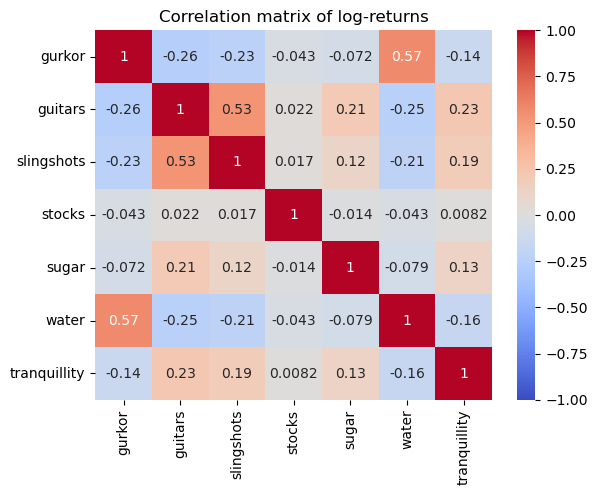

              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor          1.00    -0.26       -0.23   -0.04  -0.07   0.57         -0.14
guitars        -0.26     1.00        0.53    0.02   0.21  -0.25          0.23
slingshots     -0.23     0.53        1.00    0.02   0.12  -0.21          0.19
stocks         -0.04     0.02        0.02    1.00  -0.01  -0.04          0.01
sugar          -0.07     0.21        0.12   -0.01   1.00  -0.08          0.13
water           0.57    -0.25       -0.21   -0.04  -0.08   1.00         -0.16
tranquillity   -0.14     0.23        0.19    0.01   0.13  -0.16          1.00


In [2]:
import seaborn as sns

corrmat = log_returns.corr()
sns.heatmap(corrmat, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix of log-returns")
plt.show()

print(corrmat.round(2))

Reading the matrix:

* `gurkor` and `water` are positively correlated (~+0.57) and negatively correlated with most of the others.
* `guitars`, `slingshots`, `sugar`, `tranquillity` are positively correlated with each other.
* `stocks` has near-zero correlation with everything (all values within ±0.05).


### Log-return volatility

Looking at the size of daily moves should also tell us something. Series in the same group tend to have similar volatility.


Daily log-return std:
water           0.00350
gurkor          0.00395
tranquillity    0.01278
slingshots      0.01490
stocks          0.01491
guitars         0.01497
sugar           0.01509
dtype: float64


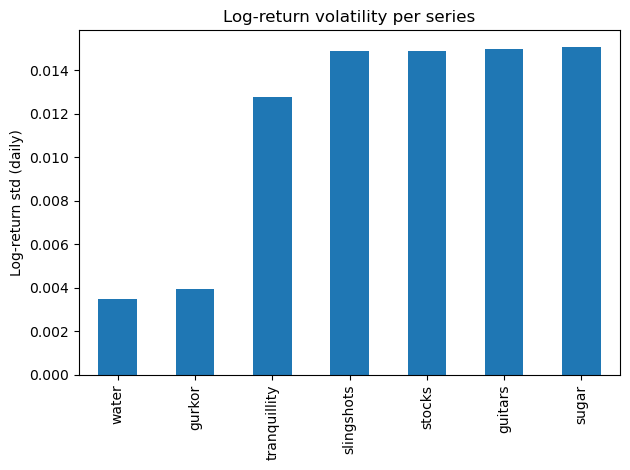

In [3]:
# daily return std for each series, sorted
vol = log_returns.std().sort_values()
print("Daily log-return std:")
print(vol.round(5))

vol.plot(kind='bar')
plt.ylabel("Log-return std (daily)")
plt.title("Log-return volatility per series")
plt.tight_layout()
plt.show()

### Conclusion: three groups

Both the correlation matrix and the volatility plot point to the same grouping:

| Group | Members | Daily log-return std | Defining feature |
|---|---|---|---|
| **A, low-volatility pair** | `gurkor`, `water` | ~0.4% | Strongly positively correlated with each other (+0.57), negatively correlated with Group B |
| **B, high-volatility cluster** | `guitars`, `slingshots`, `sugar`, `tranquillity` | ~1.3 to 1.5% | Mutually positively correlated, especially guitars and slingshots (+0.53) |
| **C, independent** | `stocks` | ~1.5% | Correlations with everything else are essentially zero |

This is useful for the next tasks:

* **Task 2 (interpolation):** when filling a gap in `gurkor`, `water` is a strong covariate. For Group B series, the other three help. For `stocks`, no other series helps, it has to be done from its own history.
* **Task 3 (extrapolation):** same idea applies. `stocks` looks like a univariate-model case.
* **Task 4 (portfolio):** the negative correlation between Groups A and B gives real diversification, and `stocks` adds a third near-independent return stream.


## Additional question: are the groups stable over time?

The grouping above is computed on the full sample. That average can hide a market that switches between regimes. If the correlation between Group A and Group B sometimes flips sign, a strategy that bets on the average correlation will lose its diversification benefit during those periods.

So: do the relationships stay the same over time, or do they change? We check this with a rolling 252-day (~one Spiff year) correlation.


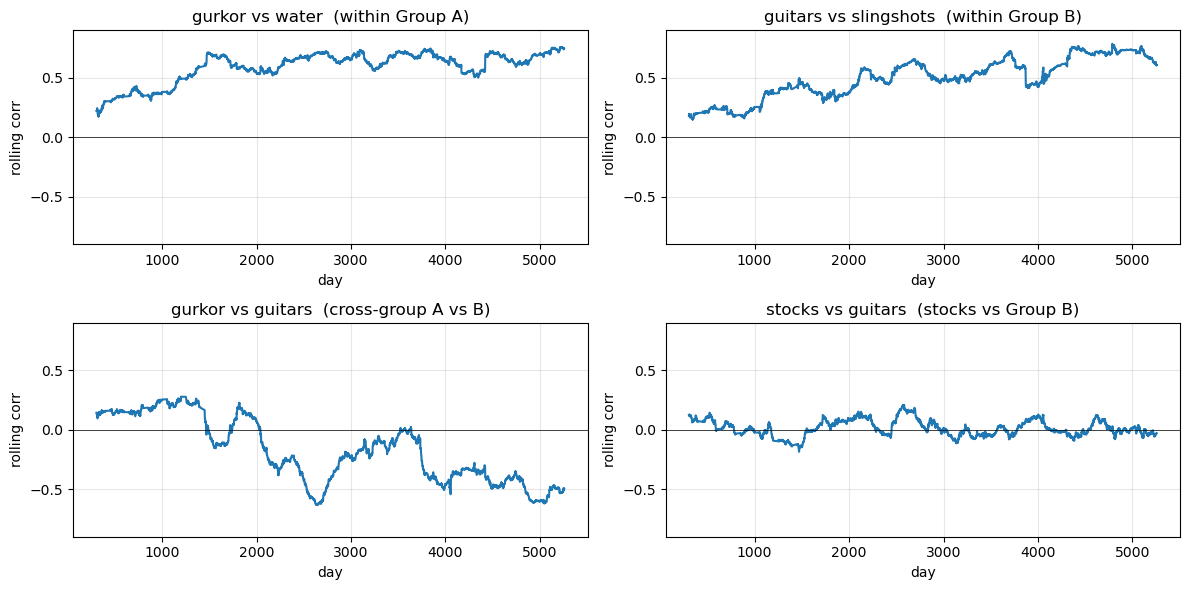

In [4]:
# Pairs that represent each "situation": within-group, cross-group, stocks-vs-rest
window = 252

pairs_to_check = [
    ('gurkor', 'water',       'within Group A'),
    ('guitars', 'slingshots', 'within Group B'),
    ('gurkor', 'guitars',     'cross-group A vs B'),
    ('stocks', 'guitars',     'stocks vs Group B'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for ax, (a, b, label) in zip(axes, pairs_to_check):
    rolling_corr = log_returns[a].rolling(window).corr(log_returns[b])
    ax.plot(rolling_corr.index, rolling_corr.values)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylim(-0.9, 0.9)
    ax.set_title(f"{a} vs {b}  ({label})")
    ax.set_xlabel("day")
    ax.set_ylabel("rolling corr")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Numerical summary of how stable each correlation is
summary = pd.DataFrame(columns=["mean", "std", "min", "max"])
for a, b, label in pairs_to_check:
    rc = log_returns[a].rolling(window).corr(log_returns[b]).dropna()
    summary.loc[f"{a} vs {b}"] = [rc.mean(), rc.std(), rc.min(), rc.max()]

print(summary.round(3))

                        mean    std    min    max
gurkor vs water        0.603  0.121  0.173  0.760
guitars vs slingshots  0.510  0.161  0.148  0.787
gurkor vs guitars     -0.199  0.260 -0.634  0.278
stocks vs guitars      0.017  0.068 -0.185  0.209


### What the rolling correlations show

* **Within Group A** (`gurkor` vs `water`): correlation stays positive across the whole sample (never drops below ~0.17). The group is stable.
* **Within Group B** (`guitars` vs `slingshots`): also stays positive, with values between ~0.15 and ~0.79.
* **Cross-group A vs B** (`gurkor` vs `guitars`): this is the unstable one. It swings between roughly -0.63 and +0.28 and crosses zero. The full-sample number (-0.26) hides a relationship that flips sign at times.
* **Stocks vs Group B** (`stocks` vs `guitars`): stays close to zero throughout (within ±0.21), confirming `stocks` is consistently independent.

**Takeaway for tasks 3 and 4:** the groups themselves are real and stable, but the negative correlation between Group A and Group B is not always there. Any strategy or model that depends on the sign of the A vs B relationship needs to either use a time-varying correlation estimate (e.g. rolling window or DCC-GARCH) or be hedged against the periods when that correlation goes positive.
